# VisA PCB1: frozen visual-inspection pilot

## tl;dr

Primary image AP **0.852**, versus baseline **0.828**. Primary recall **43.0%** and false-alarm rate **9.0%** at the normal-calibrated frozen threshold. Pixel AP **0.792**, measured at 256-square geometry including normal images.

**Recommendation: stop/revise methodology.** Both methods miss 57/100 anomalies at the frozen thresholds. Primary pooled pixel AP hides uneven small-region localization: median per-anomaly AP is0.039 and the map peak is inside the annotation for 26/100 anomalies.

This executed notebook reads saved predictions/maps and independently verified metrics. It does not retrain, change thresholds, or access a new final benchmark.

## Context & Methods

VisA PCB1 is a public controlled-defect benchmark, not Seagate data. Official training normals are split seed42 into 723 fit/181 calibration; official test has 100 normals and100 anomalies. Frozen ResNet18 layer2/layer3 features feed a GAP/L2 nearest-normal baseline and a 4096 uniform-patch **PatchCore-inspired** memory. Normal95th image/99th pixel quantiles use `higher` and strictly-greater flags. Full-board256-square resizing departs from official ImageNet preprocessing.

### Key Assumptions

Physical-board IDs are unavailable; image disjointness is not proof of unseen-object independence. Pixel AP pools spatially dependent pixels descriptively; no independent-pixel confidence intervals are claimed. Benchmark prevalence 50% does not describe factory prevalence. Commercial weight rights remain unverified.

Sources: [owner VisA](https://github.com/amazon-science/spot-diff), [official PatchCore](https://github.com/amazon-science/patchcore-inspection), and `docs/source_research.md`.

In [1]:
from pathlib import Path
import json, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
root=Path.cwd()
if root.name=='notebooks': root=root.parent
sys.path.insert(0,str(root/'src'))
from pcb_inspection.guard import digest,verify_frozen
from pcb_inspection.preprocessing import preprocess_mask
prepared=json.loads((root/'artifacts/prepared.json').read_text())
run=root/prepared['path']
protocol=json.loads((root/'docs/protocol.json').read_text())
verify_frozen(root,protocol)
verification=json.loads((run/'verification.json').read_text())
assert verification['passed'] and verification['run_id']==prepared['run_id']
assert verification['completion_sha256']==digest(run/'final_complete.json')
metrics=json.loads((run/'metrics.json').read_text())
thresholds=json.loads((run/'calibration.json').read_text())
predictions=pd.read_parquet(run/'predictions.parquet')
manifest=pd.read_csv(run/'split_manifest.csv',keep_default_na=False).set_index('image_id')
plt.rcParams.update({'font.size':11,'axes.spines.top':False,'axes.spines.right':False,'figure.dpi':130})
print('Frozen run:',prepared['run_id'],'; independently verified:',verification['passed'])

Frozen run: 31e0704ff1da6906 ; independently verified: True


## Data

All1104 source images decoded; no exclusions or exact duplicate groups. The1261 coarse training-only perceptual-hash candidates were investigated numerically on20 pairs; similar aligned boards are not assumed to be the same object. All100 masks remain nonempty after resizing.

In [2]:
audit=json.loads((root/'data/manifests/pcb1_audit.json').read_text())
pd.DataFrame([{'split/label':k,'images':v} for k,v in audit['counts'].items()])

,split/label,images
0,calibration/normal,181
1,fit/normal,723
2,test/anomaly,100
3,test/normal,100


## Results

### Ranking and frozen operating thresholds

Both methods use identical test membership. Average precision has a50% anomaly prevalence reference, rather than an expected factory prevalence.

In [3]:
columns=['average_precision','auroc','tp','fp','fn','tn','precision','recall','normal_false_alarm_rate']
pd.DataFrame({name:{key:metrics[name][key] for key in columns} for name in ['baseline','primary']}).T.round(4)

,average_precision,auroc,tp,fp,fn,tn,precision,recall,normal_false_alarm_rate
baseline,0.8276,0.7872,43.0,2.0,57.0,98.0,0.9556,0.43,0.02
primary,0.8516,0.8654,43.0,9.0,57.0,91.0,0.8269,0.43,0.09


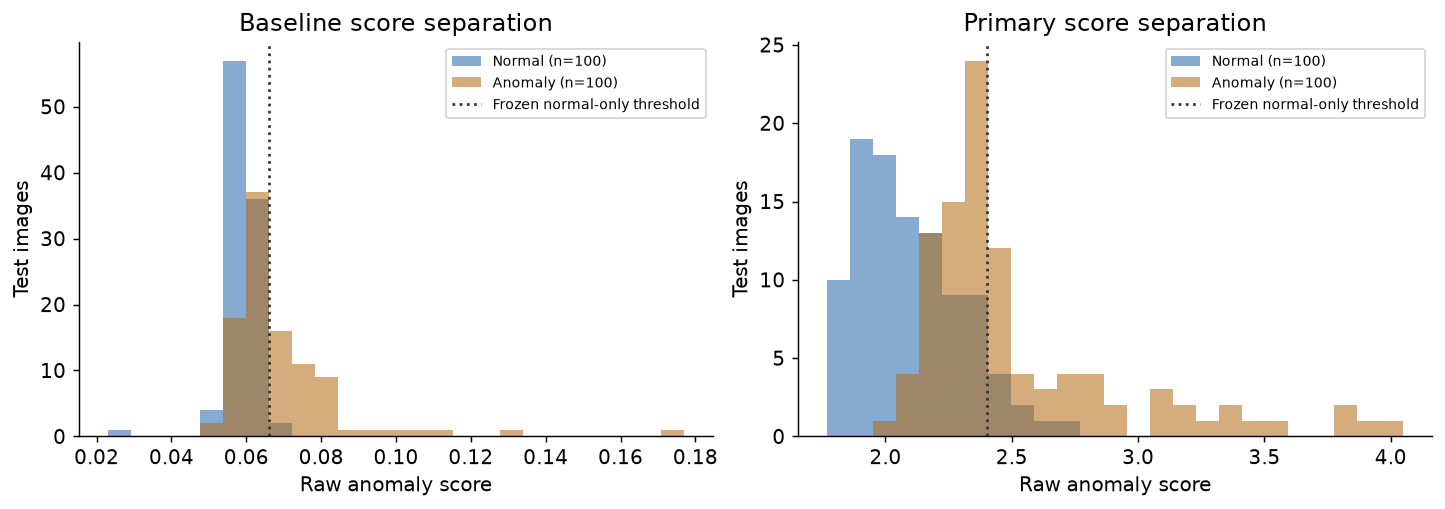

In [4]:
fig,axes=plt.subplots(1,2,figsize=(11,3.8),layout='constrained')
for ax,name in zip(axes,['baseline','primary']):
    bins=np.linspace(predictions[name+'_score'].min(),predictions[name+'_score'].max(),26)
    for label,color,style in [(0,'#2364aa','-'),(1,'#b36a13','--')]:
        ax.hist(predictions.loc[predictions.label==label,name+'_score'],bins=bins,alpha=.55,color=color,label=('Normal (n=100)' if label==0 else 'Anomaly (n=100)'),histtype='stepfilled',linestyle=style)
    ax.axvline(thresholds[name]['image_threshold'],color='#333333',linestyle=':',label='Frozen normal-only threshold')
    ax.set(title=name.capitalize()+' score separation',xlabel='Raw anomaly score',ylabel='Test images')
    ax.legend(fontsize=8)
fig.savefig(run/'score_distributions.png',bbox_inches='tight')
plt.show()

### Localization, including failure and false-alarm cases

Selection is fixed retrospectively by score: lowest-scoring anomaly, highest-scoring normal, median-scoring anomaly, and highest-scoring anomaly. These examples cannot tune the method. Mask contours are retrospective benchmark annotations, not operational model evidence. One shared raw map scale is used; no per-image normalization.

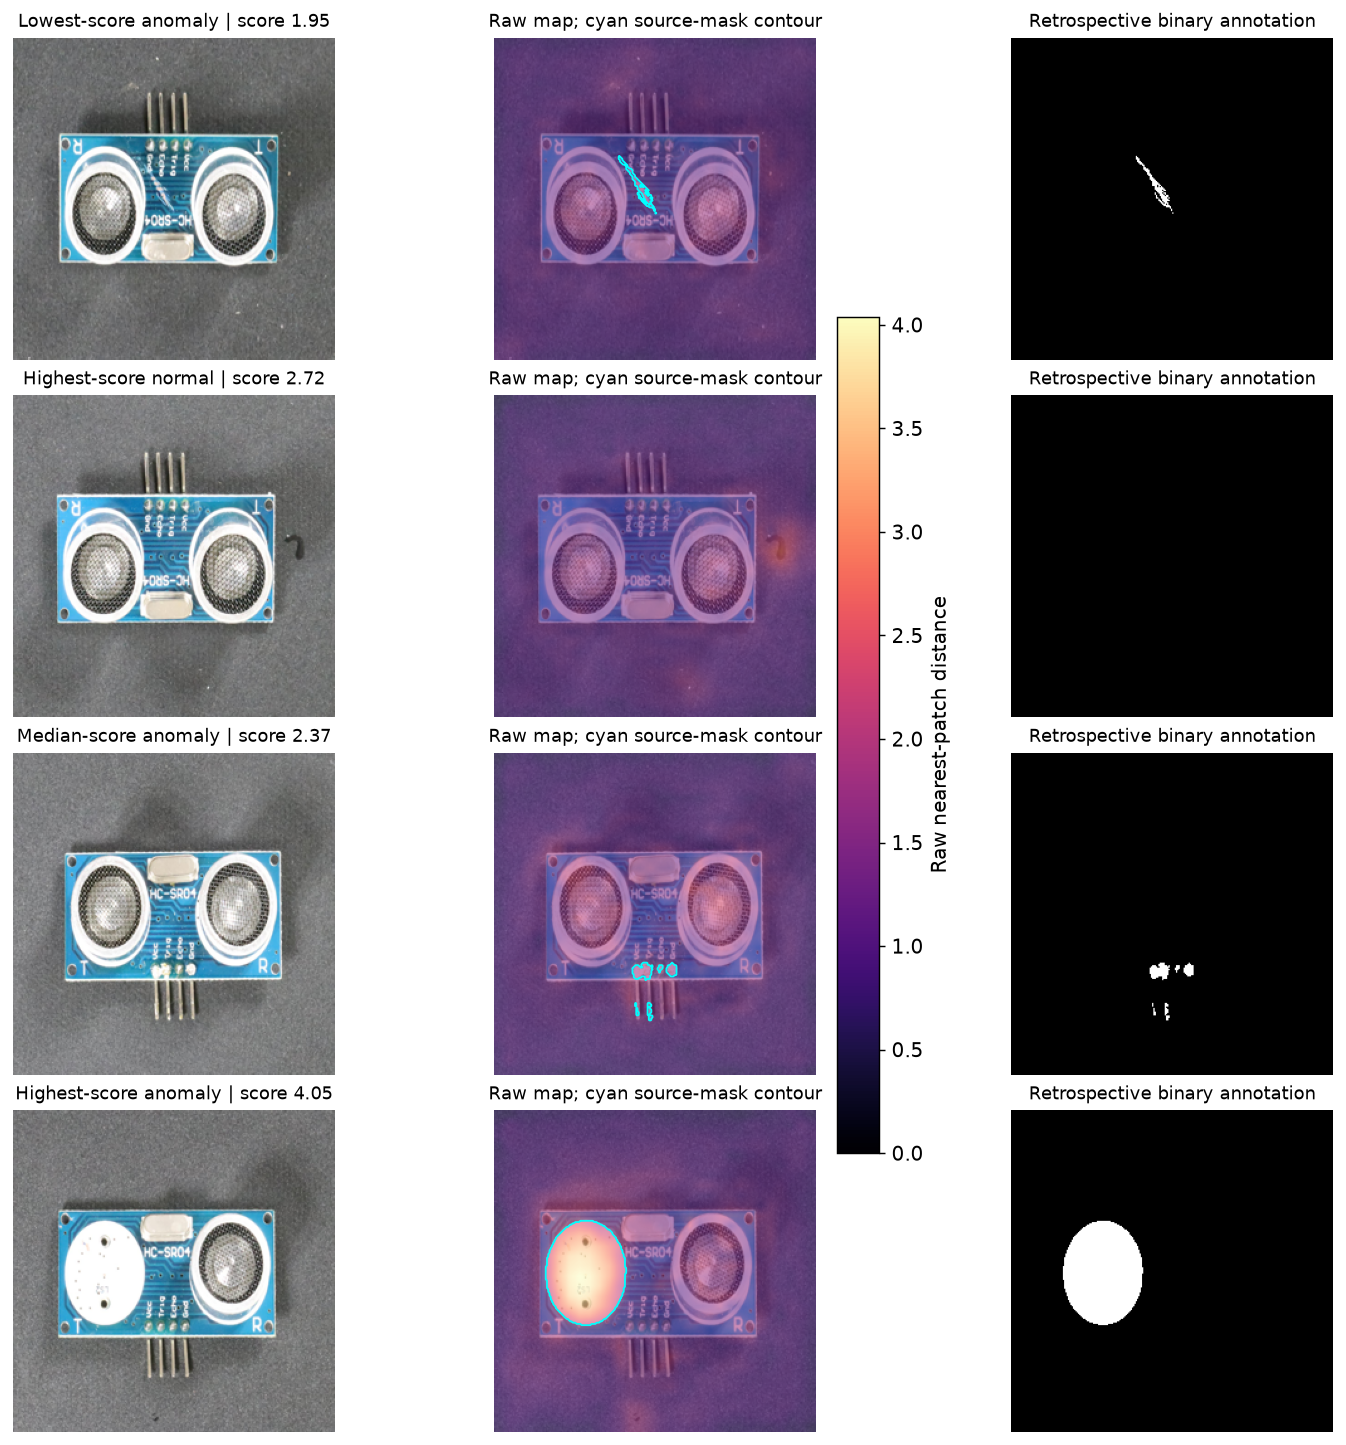

Pixel AP: 0.792 global IoU: 0.1218


In [5]:
anomalies=predictions[predictions.label==1].sort_values(['primary_score','image_id'])
normals=predictions[predictions.label==0].sort_values(['primary_score','image_id'])
selected=[anomalies.iloc[0],normals.iloc[-1],anomalies.iloc[len(anomalies)//2],anomalies.iloc[-1]]
reasons=['Lowest-score anomaly','Highest-score normal','Median-score anomaly','Highest-score anomaly']
allmap_max=max(float(np.load(run/'anomaly_maps'/f'{i}.npy').max()) for i in predictions.image_id)
fig,axes=plt.subplots(4,3,figsize=(11,11),layout='constrained')
for r,(row,reason) in enumerate(zip(selected,reasons)):
    source=manifest.loc[row.image_id]
    with Image.open(root/'data/raw'/source.image_path) as image: rgb=np.asarray(image.convert('RGB').resize((256,256)))
    amap=np.load(run/'anomaly_maps'/f'{row.image_id}.npy')
    mask=preprocess_mask(root/'data/raw'/source.mask_path) if source.mask_path else np.zeros((256,256),bool)
    axes[r,0].imshow(rgb); axes[r,0].set_title(f'{reason} | score {row.primary_score:.2f}',fontsize=10)
    axes[r,1].imshow(rgb); axes[r,1].imshow(amap,cmap='magma',vmin=0,vmax=allmap_max,alpha=.55)
    if mask.any(): axes[r,1].contour(mask,levels=[.5],colors=['cyan'],linewidths=1)
    axes[r,1].set_title('Raw map; cyan source-mask contour',fontsize=10)
    axes[r,2].imshow(mask,cmap='gray',vmin=0,vmax=1)
    axes[r,2].set_title('Retrospective binary annotation',fontsize=10)
    for ax in axes[r]: ax.axis('off')
fig.colorbar(plt.cm.ScalarMappable(norm=plt.Normalize(0,allmap_max),cmap='magma'),ax=axes[:,1],label='Raw nearest-patch distance',shrink=.6)
fig.savefig(run/'localization_examples.png',bbox_inches='tight')
plt.show()
print('Pixel AP:',round(metrics['localization']['pixel_average_precision'],4),'global IoU:',round(metrics['localization']['pixel_iou'],4))

### Uneven localization across anomalies

Pooled pixel AP weights annotation pixels, so a few large visible anomalies can dominate. This supplemental post-final check describes all 100 anomalies independently; it does not replace the predeclared pooled metric or tune the model.

{
  "scope": "Post-final descriptive check on all100 test anomalies, no tuning; excludes normals here, primary pooled pixel AP includes normals.",
  "anomalies": 100,
  "median_per_anomaly_pixel_ap": 0.03933737824864988,
  "map_peak_in_mask_count": 26,
  "positive_overlap_count": 79
}


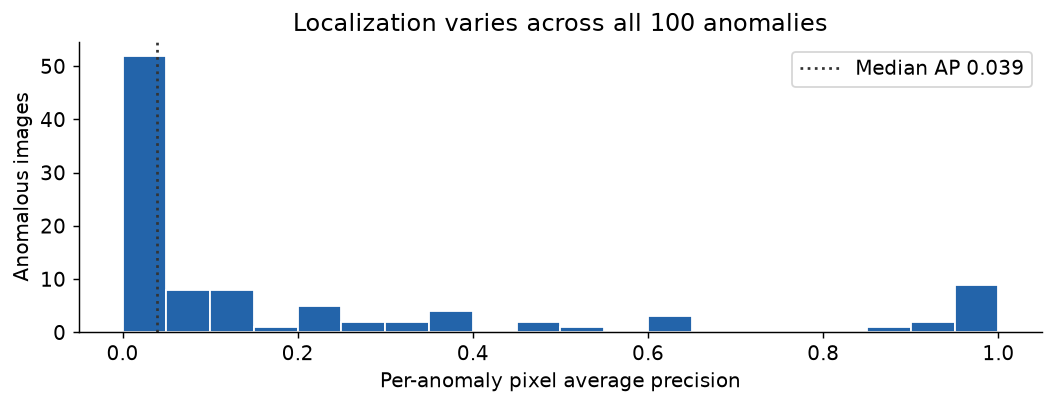

In [6]:
localization=pd.read_csv(root/'artifacts/review/anomaly_localization.csv')
summary=json.loads((root/'artifacts/review/localization_summary.json').read_text())
print(json.dumps(summary,indent=2))
fig,ax=plt.subplots(figsize=(8,3),layout='constrained')
ax.hist(localization.pixel_ap,bins=np.linspace(0,1,21),color='#2364aa',edgecolor='white')
ax.axvline(localization.pixel_ap.median(),linestyle=':',color='#333333',label=f'Median AP {localization.pixel_ap.median():.3f}')
ax.set(xlabel='Per-anomaly pixel average precision',ylabel='Anomalous images',title='Localization varies across all 100 anomalies')
ax.legend()
fig.savefig(run/'per_anomaly_localization.png',bbox_inches='tight')
plt.show()

### Runtime and reference traceability

Latency includes feature extraction and the relevant detector, measured on the actual CPU. Cold loads are separate. The two methods share features in the final loop. Independent verification checks all reference memberships/coordinates and recomputes scores plus winning patch references for three deterministic images.

In [7]:
runtime=json.loads((run/'runtime.json').read_text())
pretest=json.loads((run/'pretest_runtime.json').read_text())
print(json.dumps({'runtime':runtime,'normal_preparation':pretest,'reference_trace_samples':verification['independent_patch_traces']},indent=2))

{
  "runtime": {
    "final_eval_seconds": 65.96204700000817,
    "cold_backbone_load_seconds": 1.0260116659919731,
    "cold_reference_load_seconds": 0.005636874993797392,
    "baseline_including_features": {
      "median_seconds": 0.024119791050907224,
      "p95_seconds": 0.027996300341328606,
      "first_image_seconds": 0.026212541037239134,
      "warm_count": 199
    },
    "primary_including_features": {
      "median_seconds": 0.3069211660185829,
      "p95_seconds": 0.335487174091395,
      "first_image_seconds": 0.32050537498435006,
      "warm_count": 199
    },
    "both_including_shared_features": {
      "median_seconds": 0.3078030420001596,
      "p95_seconds": 0.3361443582747597,
      "first_image_seconds": 0.3213692079880275,
      "warm_count": 199
    },
    "process_peak_rss_bytes": 1420705792,
    "note": "Final eval timing excludes raw hashing/reference load; separate cold reference/backbone load timings recorded. Warm percentiles exclude first image. One featu

## Takeaways

**Stop/revise methodology.** Practical runtime and successful provenance checks do not overcome 57% missed anomalies or inconsistent localization. Preserve this result; do not tune against the viewed PCB1 test. Read `docs/pilot_findings.md` for the Phase A recommendation, unfavorable evidence and limits. No UI, LLM integration, remote publication or factory claim is part of this run. Small source defects, uniform-memory coverage, unknown physical-object identity, controlled acquisition and weight rights remain constraints.